# Transects and transport

This notebook demonstrates 

* how to define an oceanographic section,
* compute volume, heat, salt and freshwater transports through HYCOM output,
* visualise the spatial structure of transport across the section,
* and compare results with a dataset on a different grid (e.g. GLORYS).

**Functions covered**

| Function | Purpose |
|---|---|
| `xhycom.Transect` | Define a section from (lon, lat) waypoints |
| `Transect.resolve(grid)` | Snap the section to the HYCOM C-grid |
| `Transect.reverse()` | Flip the sign convention by reversing waypoint order |
| `xhycom.transport()` | Volume / heat / salt / freshwater transport through HYCOM |
| `xhycom.section_data()` | Hydrographic cross-section (T-point fields) |
| `xhycom.section_flux_density()` | Per-face, per-layer transport density |
| `xhycom.section_plot()` | 2-D section visualisation |
| `xhycom.transport_tpoint()` | Transport from any regular-grid dataset (e.g. GLORYS) |

In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

In [3]:
grid = xhycom.open_dataset(GRID_PATH)
bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

## 1. Define and resolve a transect

A `Transect` is a sequence of (lon, lat) waypoints and knows nothing about any particular model grid — the same object can be resolved against any grid, including any HYCOM and any lat-lon grid.

Calling `Transect.resolve(grid)` does two things:

- **T-cell path**: finds the ordered T-cells the section polyline passes through, used by `section_data` to extract hydrographic fields.
- **C-grid faces**: identifies the exact U- and V-face crossings, used by `transport` and `section_flux_density` to integrate transport without rotating or interpolating velocities.

Several common Arctic and sub-Arctic sections are built in:

In [4]:
# Available named sections
xhycom.Transect.available_names()

['barents_opening',
 'bering_strait',
 'denmark_strait',
 'fram_strait',
 'fsc',
 'gimsoy',
 'hudson_strait',
 'jones_strait',
 'kara_gate',
 'kola_section',
 'lancaster_sound',
 'robeson_channel',
 'svinoy',
 'topaz_northern',
 'topaz_southern']

Use `Transect.named()` to retrieve a built-in section:

In [5]:
fs = xhycom.Transect.named("fram_strait")
fs

Transect('fram_strait', 2 waypoints)

Built-in zonal sections are defined east → west, so positive transport is northward.  The Fram Strait waypoints are:

In [6]:
fs.lons

array([ 15., -20.])

In [7]:
fs.lats

array([79., 79.])

> **Sign convention** — positive transport is **rightward** when walking from the first to the last waypoint.
>
> Built-in zonal sections are defined east → west, so north is on your right and positive means northward:
>
> | Sign | Physical meaning at Fram Strait |
> |---|---|
> | positive | northward — Atlantic inflow (West Spitsbergen Current) |
> | negative | southward — Arctic outflow (East Greenland Current) |
>
> Call `fs.reverse()` to adopt the opposite convention (positive = southward).

You can also pass waypoints directly.  The sign convention is set entirely by their order — the example below uses the original west-to-east orientation (positive = southward), which shows both conventions are equally valid:

In [8]:
custom = xhycom.Transect(lons=[-20, 15], lats=[79, 79], name="My Fram Strait")
custom

Transect('My Fram Strait', 2 waypoints)

Now resolve against the HYCOM grid.  This is the step that ties the section geometry to a specific model grid.  The resolved object stores the T-cell path, face indices, face signs, and along-section distances — everything needed for transport and section-data calculations.

**Resolve once, reuse many times**: `resolve()` builds a KD-tree over the full T-point grid and should be called once per grid.  Pass the `ResolvedTransect` to all subsequent `transport()`, `section_data()`, and `section_flux_density()` calls.

The three plots below show the section at increasing zoom: the full domain view, a regional view around Fram Strait, and a close-up where individual T-cells and the U/V face staircase are visible.

In [9]:
fs_on_hycom = fs.resolve(grid)

In [10]:
print(f"T-cells along section : {fs_on_hycom.n_cells}")
print(f"C-grid faces crossed  : {fs_on_hycom.n_faces}")
print(f"Section length        : {fs_on_hycom.distance_km[-1]:.0f} km")

T-cells along section : 57
C-grid faces crossed  : 56
Section length        : 1035 km


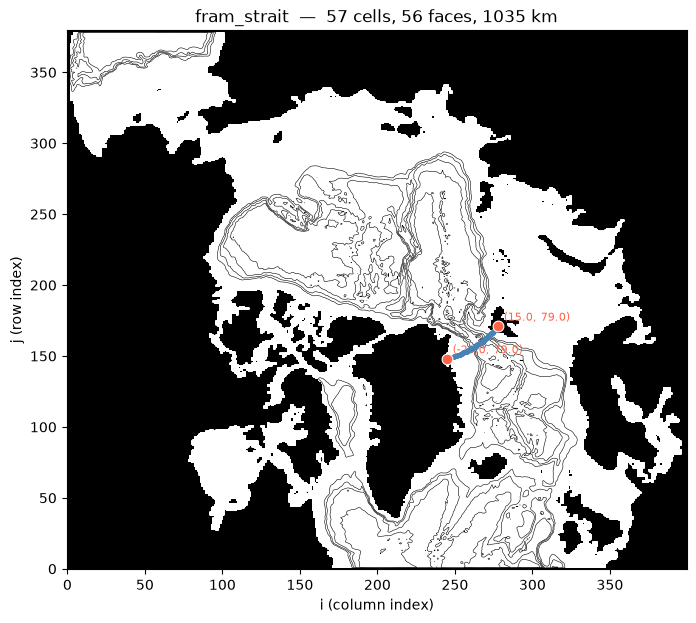

In [11]:
fs_on_hycom.plot(grid=grid, bathy=bathy, figsize=(8, 7))

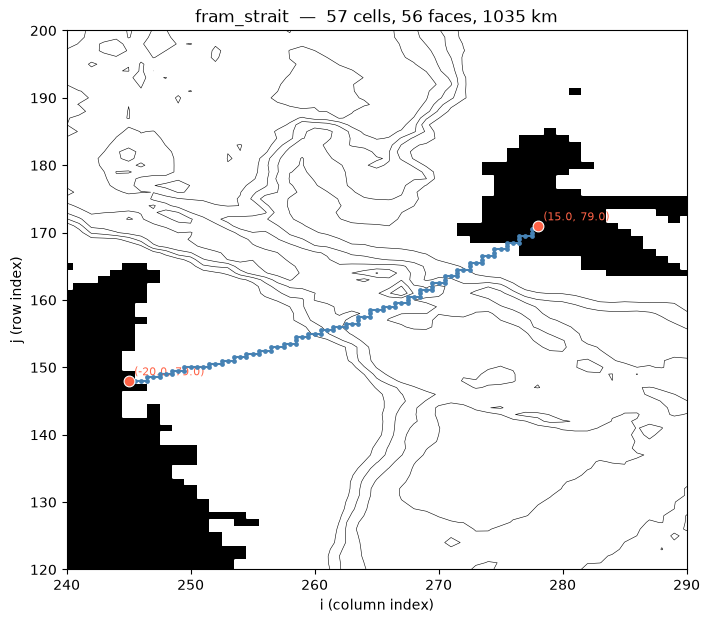

In [12]:
fs_on_hycom.plot(grid=grid, bathy=bathy, i_range=(240, 290), j_range=(120, 200), figsize=(8, 7))

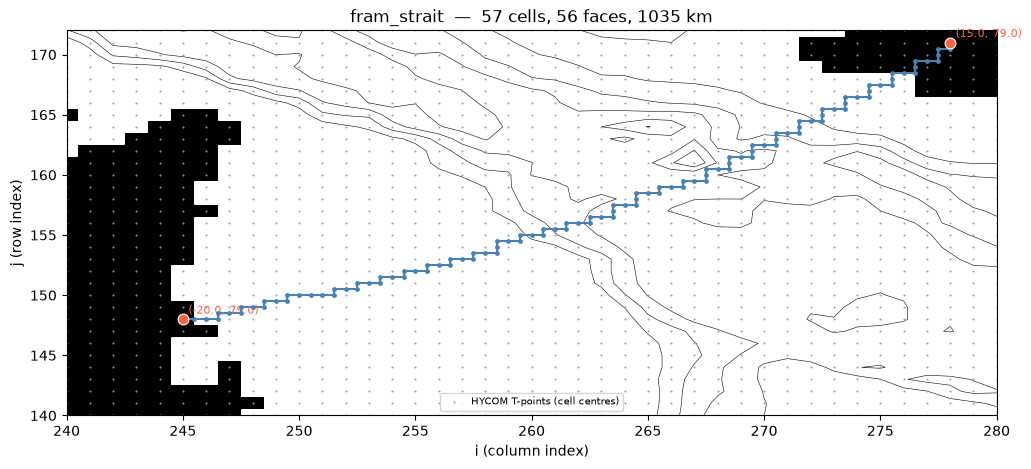

In [13]:
fs_on_hycom.plot(grid=grid, bathy=bathy, show_cells=True, i_range=(240, 280), j_range=(140, 172), figsize=(12, 5))

Here is a plot of all pre-defined sections.

In [10]:
named_resolved = {
    name: xhycom.Transect.named(name).resolve(grid)
    for name in xhycom.Transect.available_names()
    if not name.startswith("topaz")
}

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

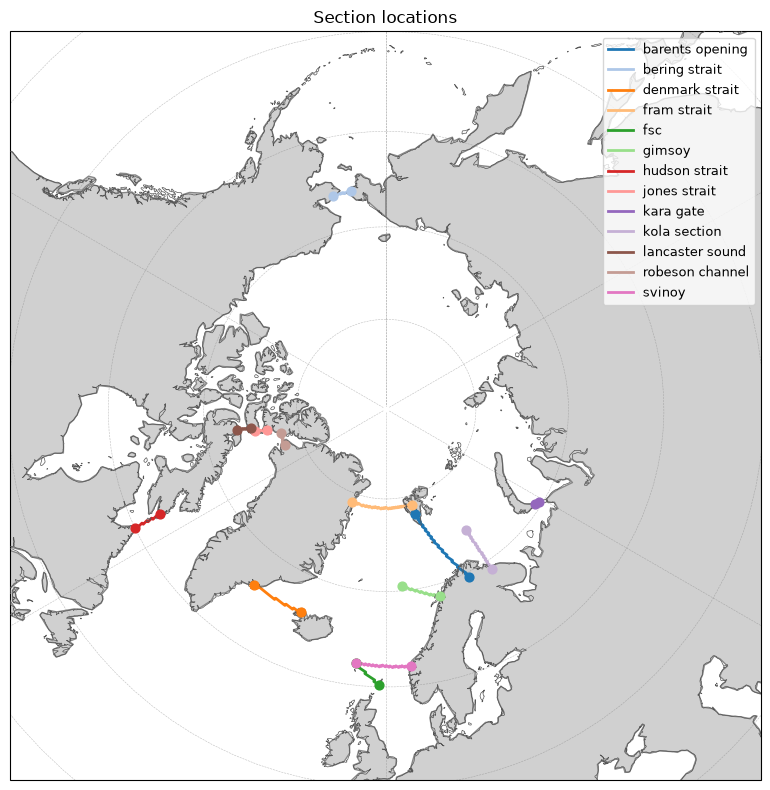

In [13]:
proj = ccrs.NorthPolarStereo(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#d0d0d0", edgecolor="#888", zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="#555", linewidth=0.5, zorder=3)
ax.gridlines(linewidth=0.4, linestyle="--", color="grey", alpha=0.5)

colors = plt.cm.tab20.colors
for idx, (name, rt) in enumerate(named_resolved.items()):
    col = colors[idx % len(colors)]
    ax.plot(rt.cell_lon, rt.cell_lat, transform=ccrs.PlateCarree(),
            color=col, lw=2, label=name.replace("_", " "))
    ax.scatter(rt.cell_lon[[0, -1]], rt.cell_lat[[0, -1]],
               transform=ccrs.PlateCarree(), color=col, s=40, zorder=5)

ax.legend(loc="upper right", fontsize=9, framealpha=0.8)
ax.set_title("Section locations", fontsize=12)
plt.tight_layout()

## 2. Volume, heat, salt and freshwater transport

In [14]:
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

`transport()` integrates velocity and tracer fields over the resolved C-grid faces.  It uses `u-vel.` and `v-vel.` directly at their staggered U/V face locations — no rotation to T-points is needed.  Layer thickness and tracer values are averaged from the two T-cells straddling each face.

In [15]:
%time tr = xhycom.transport(ds, fs_on_hycom)

CPU times: user 1.64 s, sys: 24 ms, total: 1.66 s
Wall time: 2.8 s


The result is a small `xr.Dataset` with one scalar time series per transport variable.

Note that the call returns instantly because all arrays are Dask-backed — no data has been computed yet.  Computation is deferred until explicitly requested.

In [16]:
tr

<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
Data variables:
    volume   (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    heat     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    salt     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    fw       (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>

Loading all four transport variables for a full year triggers the actual computation.  Wall time scales with the number of time steps; chunking by time (as done above) keeps memory usage low.

In [17]:
%time tr.load()

CPU times: user 1min 14s, sys: 14.8 s, total: 1min 29s
Wall time: 1min 47s


<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
Data variables:
    volume   (time) float64 3kB -0.9277 6.483 12.51 9.375 ... 10.34 3.615 -2.068
    heat     (time) float64 3kB -9.087 -11.18 -17.13 ... -7.781 -18.77 -16.63
    salt     (time) float64 3kB -3.543e+07 2.291e+08 ... 1.282e+08 -7.44e+07
    fw       (time) float64 3kB 0.06562 0.06073 0.04702 ... 0.02051 0.01728

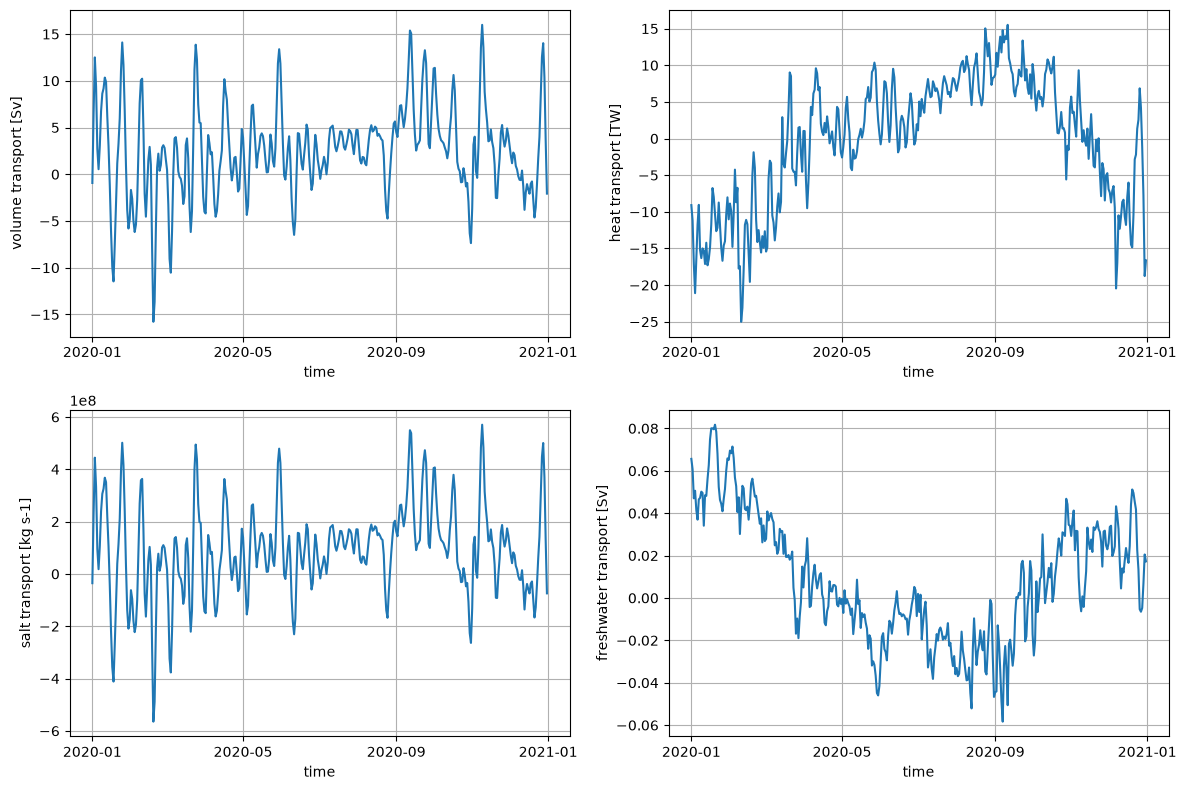

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

tr.volume.plot(ax=axs[0, 0])
tr.heat.plot(ax=axs[0, 1])
tr.salt.plot(ax=axs[1, 0])
tr.fw.plot(ax=axs[1, 1])

for ax in axs.flatten():
    ax.grid()
    
plt.tight_layout()

### Constrained transports — separating water masses

Pass `constraints` to zero out face-layer contributions where a tracer condition is not met.  Multiple constraints are AND-ed.  The tracer value at each face is the average of the two neighbouring T-cells.

This cleanly separates inflow and outflow by water-mass class.  By construction the constrained transports sum to the total: `tr_aw + tr_pw ≈ tr`.

In [19]:
%%time

# Atlantic Water: T > 1 °C
tr_aw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("gt", 1.0)}).compute()
# Polar/Arctic Water: T ≤ 1 °C
tr_pw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("le", 1.0)}).compute()

CPU times: user 2min 34s, sys: 28.1 s, total: 3min 2s
Wall time: 3min 24s


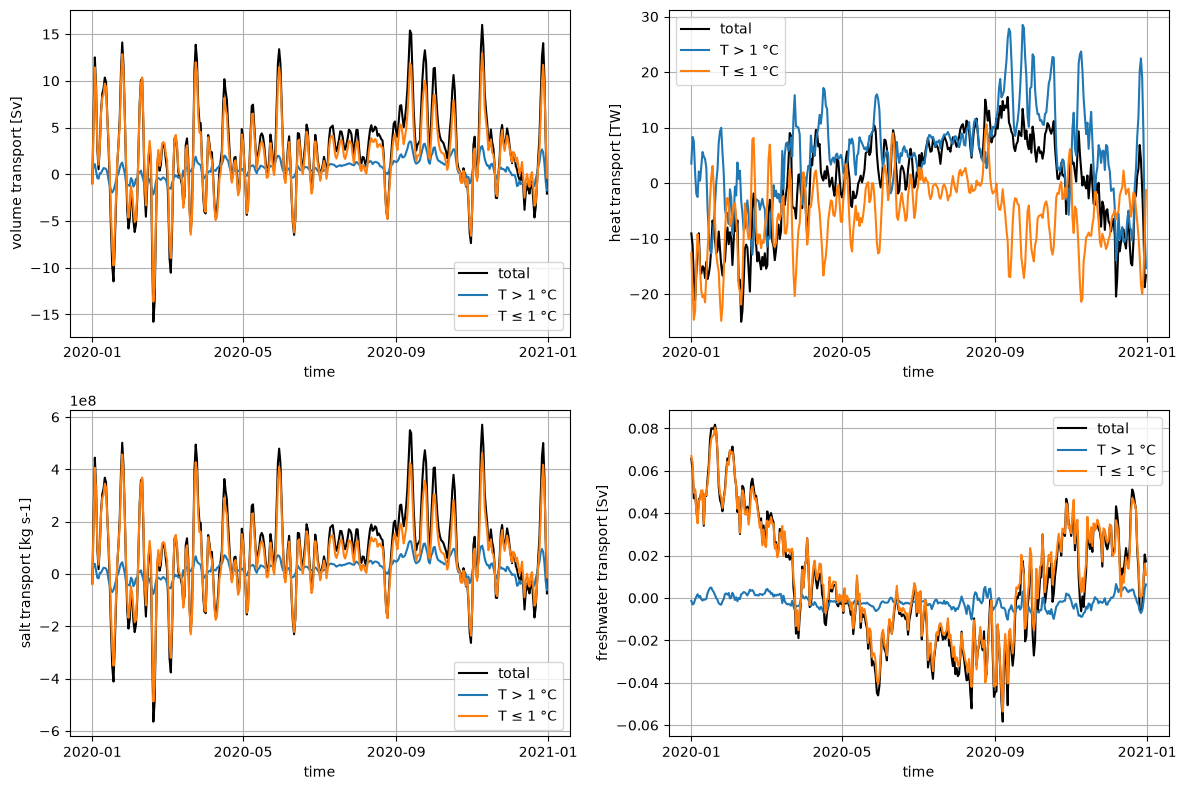

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

tr.volume.plot(ax=axs[0, 0], color="k", label="total")
tr_aw.volume.plot(ax=axs[0, 0], label="T > 1 °C")
tr_pw.volume.plot(ax=axs[0, 0], label="T ≤ 1 °C")

tr.heat.plot(ax=axs[0, 1], color="k", label="total")
tr_aw.heat.plot(ax=axs[0, 1], label="T > 1 °C")
tr_pw.heat.plot(ax=axs[0, 1], label="T ≤ 1 °C")

tr.salt.plot(ax=axs[1, 0], color="k", label="total")
tr_aw.salt.plot(ax=axs[1, 0], label="T > 1 °C")
tr_pw.salt.plot(ax=axs[1, 0], label="T ≤ 1 °C")

tr.fw.plot(ax=axs[1, 1], color="k", label="total")
tr_aw.fw.plot(ax=axs[1, 1], label="T > 1 °C")
tr_pw.fw.plot(ax=axs[1, 1], label="T ≤ 1 °C")


for ax in axs.flatten():
    ax.grid()
    ax.legend()
    
plt.tight_layout()

---

## 3. Hydrographic cross-section

`section_data()` extracts any model variable along the T-cell path, returning a `(section, k)` Dataset with `distance_km` and `depth_m` coordinates ready for cross-section plots.  The `section` dimension spans the T-cells identified by `resolve()`; `distance_km` is the cumulative great-circle distance from the first T-cell.

In [21]:
sec = xhycom.section_data(ds, fs_on_hycom)
sec

<xarray.Dataset> Size: 448MB
Dimensions:      (section: 57, time: 366, k: 50, ki: 51)
Coordinates:
    lon          (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    lat          (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    lon_u        (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    lat_u        (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    lon_v        (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    lat_v        (section) float64 456B dask.array<chunksize=(57,), meta=np.ndarray>
    distance_km  (section) float64 456B 0.0 18.2 36.42 ... 1.016e+03 1.035e+03
  * time         (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
  * k            (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens         (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki           (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
Dimensions without coordinates: section
Data variables: (12/84)
    montg1       (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    srfhgt       (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    oneta        (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    surflx       (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    wtrflx       (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    salflx       (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    ...           ...
    ECO_bots     (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    surface__1   (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    surface__2   (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    si_u         (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    si_v         (time, section) float64 167kB dask.array<chunksize=(1, 57), meta=np.ndarray>
    depth_m      (time, k, section) float64 8MB dask.array<chunksize=(1, 50, 57), meta=np.ndarray>

In [22]:
sec0 = sec.isel(time=0)

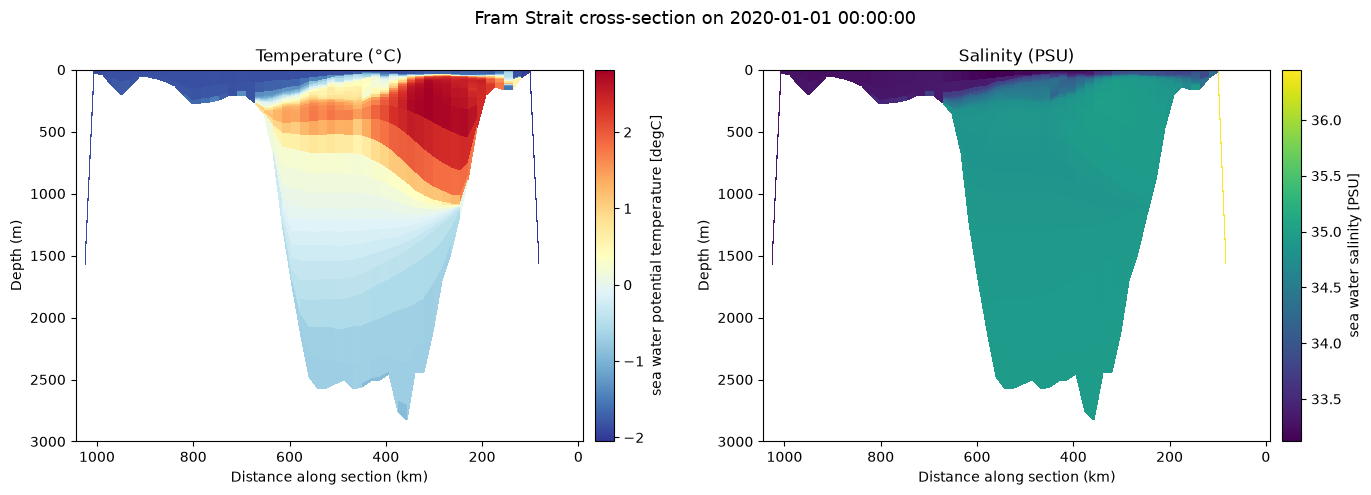

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec0, "temp", 
    ax=axes[0],
    cmap="RdYlBu_r",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Temperature (°C)"
)

xhycom.section_plot(
    sec0, "salin", 
    ax=axes[1],
    cmap="viridis",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Salinity (PSU)"
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

> **x-axis orientation** — the x-axis runs from east (left, 0 km) to west (right, ~1035 km), matching the east → west waypoint order of the built-in Fram Strait transect.  To show the Fram Strait with west on the left in the above plot, we passed `flip_x=True` to `section_plot`.

---

## 4. Transport structure — where does the transport come from?

`section_flux_density()` returns the **signed transport density** `v_normal × dz` (m² s⁻¹) at every C-grid face and vertical layer.  The sign follows the same rightward convention as `transport()`.

Integrating: `(flux_density × face_width_m).sum(["k", "face"])` recovers the total volume transport from `tr.volume`.  Plotting the unintegrated density reveals the spatial structure — which part of the section and which depth range carries the inflow vs outflow.

> **Note**: `heat_flux_density`, `salt_flux_density`, and `fw_flux_density` are the corresponding tracer-weighted fields.  The same integration recovers `tr.heat`, `tr.salt`, and `tr.fw` (after applying the same unit scale factors as `transport()`).  See the `section_flux_density` docstring for details.

In [24]:
sec_flux = xhycom.section_flux_density(ds, fs_on_hycom)
sec_flux

<xarray.Dataset> Size: 41MB
Dimensions:            (face: 56, k: 50, time: 366)
Coordinates:
    lon                (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    lat                (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    lon_u              (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    lat_u              (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    lon_v              (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    lat_v              (face) float64 448B dask.array<chunksize=(28,), meta=np.ndarray>
    distance_km        (face) float64 448B 9.101 27.31 ... 1.007e+03 1.026e+03
    face_width_m       (face) float64 448B 1.82e+04 1.821e+04 ... 1.871e+04
  * k                  (k) int64 400B 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50
    dens               (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * time               (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 0...
Dimensions without coordinates: face
Data variables:
    flux_density       (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 28), meta=np.ndarray>
    depth_m            (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 28), meta=np.ndarray>
    heat_flux_density  (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 28), meta=np.ndarray>
    salt_flux_density  (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 28), meta=np.ndarray>
    fw_flux_density    (time, k, face) float64 8MB dask.array<chunksize=(1, 50, 28), meta=np.ndarray>

In [25]:
sec_flux0 = sec_flux.isel(time=0)

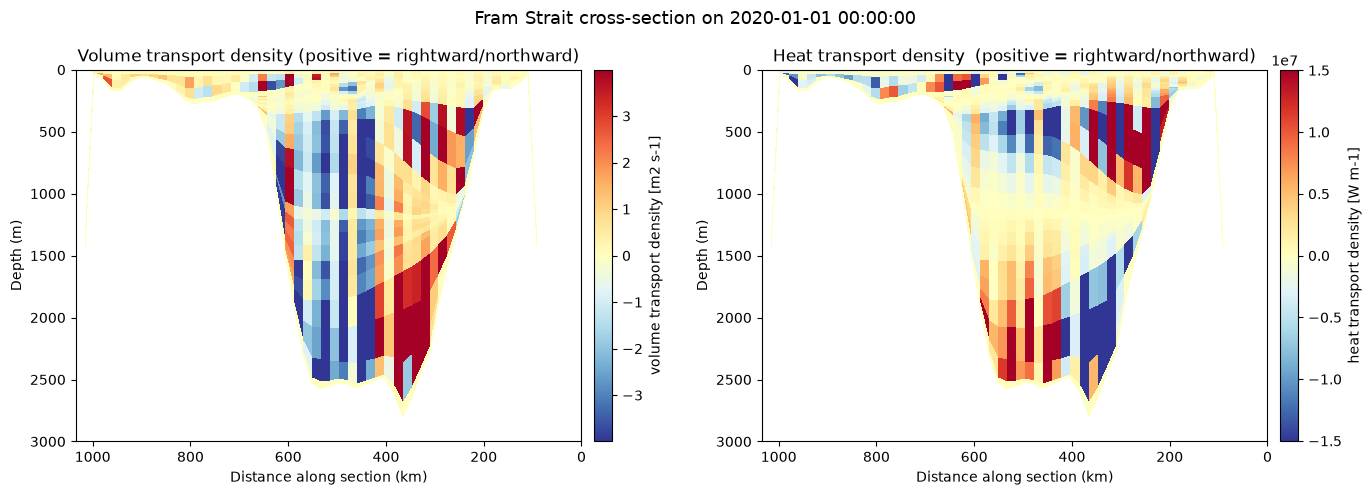

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec_flux0, "flux_density", 
    ax=axes[0],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Volume transport density (positive = rightward/northward)",
)

xhycom.section_plot(
    sec_flux0, 
    "heat_flux_density", 
    ax=axes[1],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Heat transport density  (positive = rightward/northward)",
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

---

## 5. Comparing with another dataset

In [31]:
glorys_data = xr.open_mfdataset(
    "/nird/datapeak/NS9481K/MERCATOR_DATA/PHY/2020/MERCATOR-PHY-24-2020-*.nc", chunks={"time": 1}
)

In [32]:
glorys_data

<xarray.Dataset> Size: 2TB
Dimensions:    (time: 366, depth: 50, latitude: 721, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 3kB 30.0 30.08 30.17 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    so         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 9GB dask.array<chunksize=(1, 721, 4320), meta=np.ndarray>
Attributes:
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    Conventions:               CF-1.4
    comment:                   CMEMS product
    institution:               MERCATOR OCEAN
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    references:                http://www.mercator-ocean.fr
    copernicusmarine_version:  2.0.1


`transport_tpoint()` computes the same four transports for any dataset carrying eastward/northward velocity components on a regular or rectilinear lat–lon grid — no regridding onto the HYCOM grid needed. A typical use case is comparing HYCOM output against GLORYS or another reanalysis.

The function finds the nearest grid cell to each point on the transect polyline, projects the velocity components onto the section-normal direction, and integrates over depth and along-section width.  The sign convention is identical to `transport()`: positive = rightward when walking from the first to the last waypoint.

In [35]:
tr_glorys = xhycom.transport_tpoint(
    glorys_data, fs,
    u_var="uo", v_var="vo",
    t_var="thetao", s_var="so",
    lat_dim="latitude", lon_dim="longitude", z_dim="depth",
)

In [36]:
tr_glorys

<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    volume   (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    heat     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    salt     (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    fw       (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>

In [37]:
%time tr_glorys.load()

CPU times: user 7min 28s, sys: 33min 52s, total: 41min 20s
Wall time: 52min 18s


<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    volume   (time) float64 3kB 1.54 -2.84 -5.963 ... -5.246 -3.994 -4.813
    heat     (time) float64 3kB 35.89 40.7 49.42 57.32 ... 90.58 72.55 54.17
    salt     (time) float64 3kB 5.699e+07 -1.007e+08 ... -1.411e+08 -1.704e+08
    fw       (time) float64 3kB -0.05732 -0.01798 -0.03228 ... -0.03714 -0.03542

In [45]:
# HYCOM encodes time as cftime.DatetimeGregorian; GLORYS uses numpy datetime64.
# Matplotlib cannot render both on the same axis, so convert HYCOM to datetime64.
tr_pd = tr.assign_coords(time=tr.indexes["time"].to_datetimeindex(time_unit="ns"))

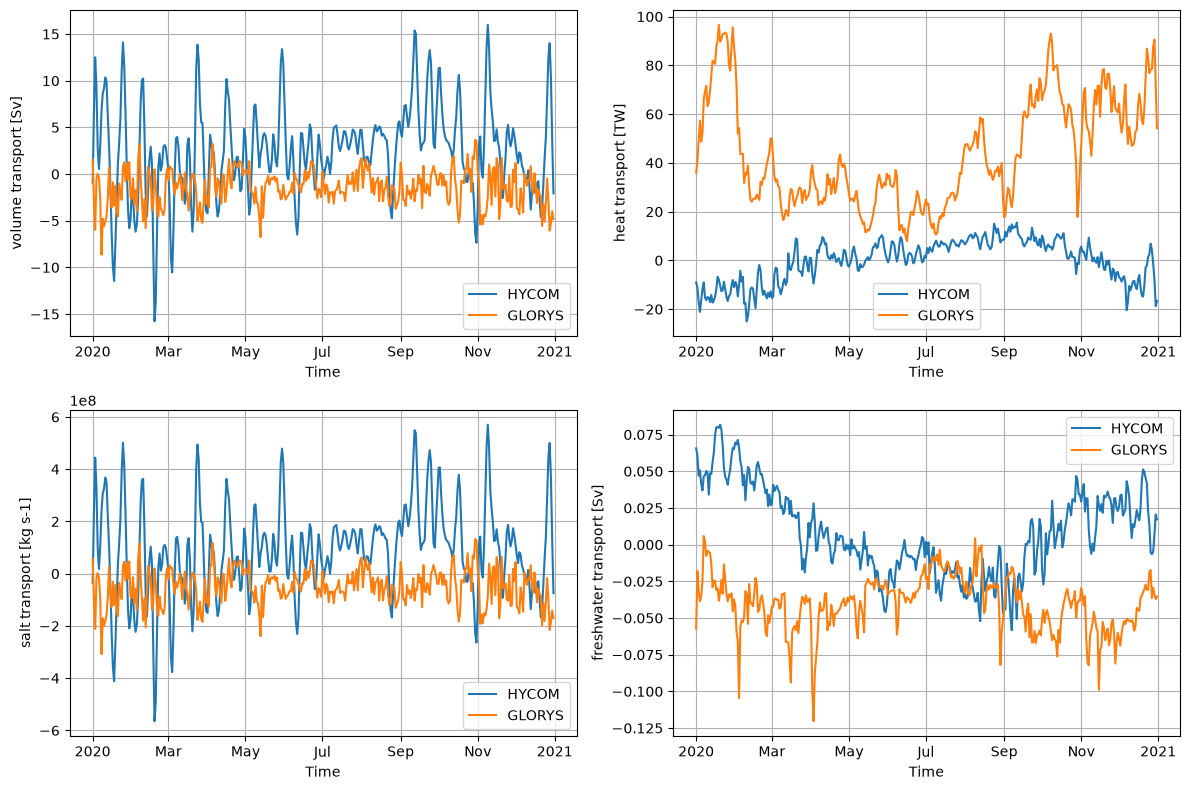

In [46]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

tr_pd.volume.plot(ax=axs[0, 0], label="HYCOM")
tr_glorys.volume.plot(ax=axs[0, 0], label="GLORYS")

tr_pd.heat.plot(ax=axs[0, 1], label="HYCOM")
tr_glorys.heat.plot(ax=axs[0, 1], label="GLORYS")

tr_pd.salt.plot(ax=axs[1, 0], label="HYCOM")
tr_glorys.salt.plot(ax=axs[1, 0], label="GLORYS")

tr_pd.fw.plot(ax=axs[1, 1], label="HYCOM")
tr_glorys.fw.plot(ax=axs[1, 1], label="GLORYS")

for ax in axs.flatten():
    ax.grid()
    ax.legend()
    
plt.tight_layout()

---

## Tips and gotchas

**Sign convention** — positive transport is always to the *right* when walking from `lons[0]` to `lons[-1]`.  Built-in zonal sections are defined east → west so that positive = northward.  Call `Transect.reverse()` to adopt the opposite convention, or negate the result.

**Total vs baroclinic velocity** — for instantaneous HYCOM archives (`archv.*`), open with `postprocess=True` or call `xhycom.postprocess(ds)` explicitly.  Without postprocessing, `u-vel.` contains only the baroclinic component and transports will be wrong.

**Thickness units** — `thknss` is stored in Pa in HYCOM archives.  `postprocess` converts it to metres; `transport()` and `section_data()` auto-detect both units, so either form works.

**Cross-grid comparison** — `transport_tpoint` expects velocities in true east/north geographic components.  GLORYS/Copernicus products provide `uo`/`vo` in geographic axes already.  If you interpolated HYCOM velocities onto a regular grid first, rotate them with `xhycom.velocities_east_north(ds, grid)` beforehand.

**Lazy / Dask datasets** — all functions work with Dask-backed datasets.  Call `.compute()` to force evaluation, or pass multiple arrays to `dask.compute()` for efficient parallel loading.